In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Load dataset
df = pd.read_csv("E:/Project/Submissions/Datasets/df_reduced_pca.csv", parse_dates=['date'], date_format='%Y-%m-%d')

# Convert 'date' to datetime format
df['day'] = pd.to_datetime(df['day'])
# Set date as index
df.set_index('day', inplace=True)

# Selecting target variable (energy_sum as an example)
target_col = 'energy_sum'
df_re = df[target_col]
df_resampled = df_re.resample('W').mean()  # Resampling to daily mean if your index is datetime

# Drop rows with NaN values
df_resampled = df_resampled.dropna()

In [3]:
# Select exogenous variables (excluding target 'energy_sum' and 'date' column)
exog_cols = ['month', 'partly-cloudy-night', 'cloudy', 'temperatureHigh', 
             'visibility']# 'windSpeed', 'rain', 'moonPhase', 'clear-day', 'pressure', 'uvIndex']

df_exog = df[exog_cols].resample('W').mean().dropna()

In [4]:
# Ensure exogenous variables and target have the same index
df_exog = df_exog.loc[df_resampled.index]

In [5]:
# Train-Test Split (80% train, 20% test)
train_size = int(len(df_resampled) * 0.8)
train_y, test_y = df_resampled[:train_size], df_resampled[train_size:]
train_exog, test_exog = df_exog[:train_size], df_exog[train_size:]

In [6]:
# Use auto_arima to find optimal (p,d,q) order
auto_arima_model = auto_arima(train_y, exogenous=train_exog, seasonal=True, m=52, trace=True,
                              error_action='ignore', suppress_warnings=True, stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[52] intercept   : AIC=-64.401, Time=3.86 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=-61.753, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=-67.504, Time=0.65 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=-68.799, Time=0.60 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=-63.400, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=-61.485, Time=0.05 sec
 ARIMA(0,1,1)(1,0,1)[52] intercept   : AIC=-66.799, Time=0.80 sec
 ARIMA(0,1,1)(0,0,2)[52] intercept   : AIC=-66.799, Time=3.18 sec
 ARIMA(0,1,1)(1,0,0)[52] intercept   : AIC=-68.799, Time=0.72 sec
 ARIMA(0,1,1)(2,0,0)[52] intercept   : AIC=-66.799, Time=4.81 sec
 ARIMA(0,1,1)(2,0,1)[52] intercept   : AIC=-64.799, Time=4.20 sec
 ARIMA(0,1,0)(1,0,0)[52] intercept   : AIC=-67.560, Time=0.43 sec
 ARIMA(1,1,1)(1,0,0)[52] intercept   : AIC=-69.035, Time=1.59 sec
 ARIMA(1,1,1)(0,0,0)[52] intercept   : AIC=-60.641, Time=0.10 sec
 ARIMA(1,1,1)(2,0,0)[52] intercep

In [7]:
best_order = auto_arima_model.order  # (p,d,q) values
best_seasonal_order = auto_arima_model.seasonal_order  # (P,D,Q,s) values

In [8]:

# Fit SARIMAX model
sarimax_model = SARIMAX(train_y, exog=train_exog, 
                        order=best_order,#(1, 0, 1), 
                        seasonal_order=best_seasonal_order,#(1, 0, 1, 52), 
                        enforce_stationarity=False, 
                        enforce_invertibility=False)
sarimax_result = sarimax_model.fit()


C:\Users\ABCD\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [9]:
future_exog = df_exog.iloc[-52:].copy()  # Repeat last 52 weeks


In [10]:

# Forecast for the next 52 steps using future exogenous variables
forecast_obj = sarimax_result.get_forecast(steps=52, exog=future_exog)
forecast_mean = forecast_obj.predicted_mean

# Forecast
forecast = sarimax_result.forecast(steps=len(test_y), exog=test_exog)



In [19]:
# Evaluate model
mae = mean_absolute_error(test_y, forecast)
mse = mean_squared_error(test_y, forecast)
rmse = np.sqrt(mse)  # RMSE is the square root of MSE

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 0.22
Mean Squared Error (MSE): 0.08
Root Mean Squared Error (RMSE): 0.28


In [12]:
test_data = df[target_col].iloc[-52:]  # Last 52 values as test set


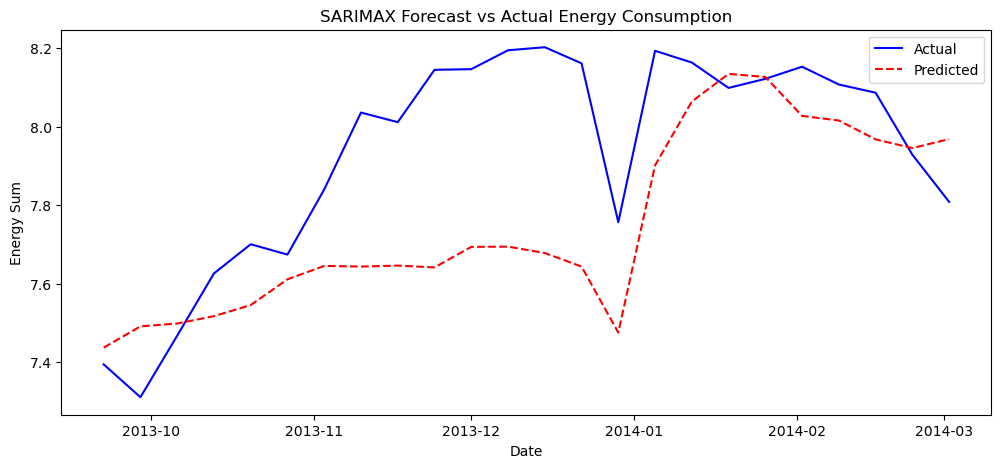

In [14]:
# Plot actual vs predicted values
plt.figure(figsize=(12, 5))
plt.plot(test_y, label="Actual", color='blue')
plt.plot(forecast, label="Predicted", color='red', linestyle='dashed')
plt.xlabel("Date")
plt.ylabel("Energy Sum")
plt.title("SARIMAX Forecast vs Actual Energy Consumption")
plt.legend()
plt.show()

In [15]:
steps_ahead = 52  # 12 months for weekly data
future_forecast = sarimax_result.forecast(steps=steps_ahead, exog=future_exog)

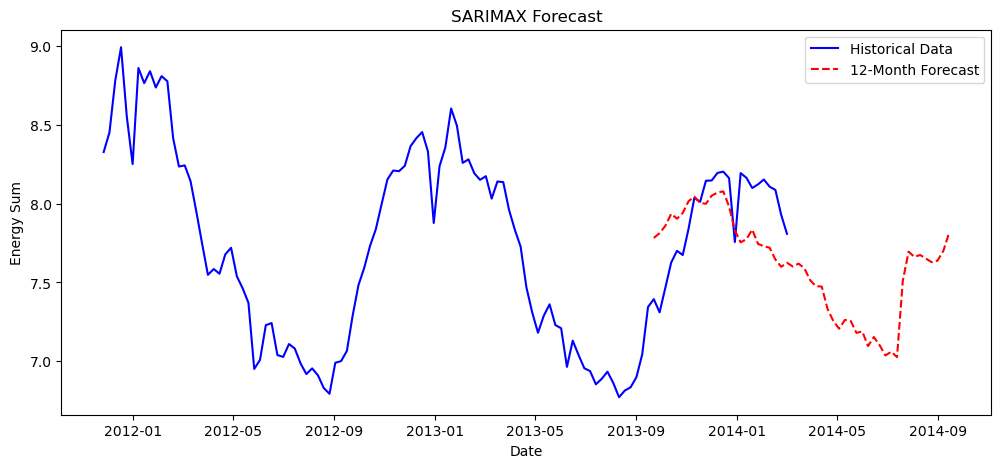

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(df_resampled, label="Historical Data", color='blue')
plt.plot(future_forecast, label="12-Month Forecast", color='red', linestyle='dashed')
plt.xlabel("Date")
plt.ylabel("Energy Sum")
plt.title("SARIMAX Forecast")
plt.legend()
plt.show()
